# Running a Parameter Sweep

This notebook demonstrates how to compute $T_c(d_F)$ curves for
**multiple ferromagnets** on the same plot, allowing direct comparison
of how exchange energy and coherence length affect the proximity effect.

## Setup

We compare four ferromagnets coupled to a **Nb** superconductor.
The interface transparency $\gamma$ encodes the ratio
$\sigma_F \xi_S / (\sigma_S d_S)$, so it scales inversely with
the S-layer thickness. We use $\gamma = 0.3$ at $d_S = 30\,\text{nm}$
as the reference point.

| Material | $E_{\text{ex}}$ (meV) | $\xi_F$ (nm) | Oscillation period $\pi\xi_F$ | Character |
|----------|----------------------:|-------------:|-----------------------------:|----------|
| Fe       | 256                   | 0.7          | 2.2 nm                      | Strong: rapid oscillation, short range |
| Co       | 309                   | 0.5          | 1.6 nm                      | Strong: fastest decay |
| Ni       | 75                    | 2.3          | 7.2 nm                      | Moderate: clearly visible oscillation |
| Py       | 20                    | 5.0          | 15.7 nm                     | Weak: broad, slow oscillation |

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import numpy as np
import matplotlib.pyplot as plt
import supermag

supermag.apply_theme("dark")

nb = supermag.get_material("Nb")
d_F = np.linspace(0.5, 40.0, 300)

# Reference coupling: gamma encodes sigma_F*xi_S / (sigma_S*d_S)
# We define gamma_ref at d_S_ref, then scale for other d_S values.
d_S_ref = 30.0   # nm
gamma_ref = 0.3   # reference interface transparency

print(f"Superconductor: Nb (Tc0 = {nb['Tc']} K, ξ_S = {nb['xi_S']} nm)")
print(f"Reference: d_S = {d_S_ref} nm, γ = {gamma_ref}")
print(f"d_F range: {d_F[0]} – {d_F[-1]} nm ({len(d_F)} points)")

Superconductor: Nb (Tc0 = 9.2 K, ξ_S = 38.0 nm)
Reference: d_S = 30.0 nm, γ = 0.3
d_F range: 0.5 – 40.0 nm (300 points)


## Multi-Material Sweep

Loop over ferromagnets and compute $T_c(d_F)$ for each at the reference
$d_S = 30\,\text{nm}$, $\gamma = 0.3$. The key physics to observe:

- **Stronger ferromagnets** (larger $E_{\text{ex}}$, smaller $\xi_F$) suppress
  $T_c$ more rapidly and oscillate on a shorter length scale
- **Weaker ferromagnets** show more gradual suppression with longer oscillation
  periods — Ni and Py exhibit the dip–recovery pattern from the FFLO-like
  pair amplitude oscillation
- The oscillation period is set by $\pi\xi_F$ — Fe and Co oscillate so fast
  that only the initial dip is resolvable

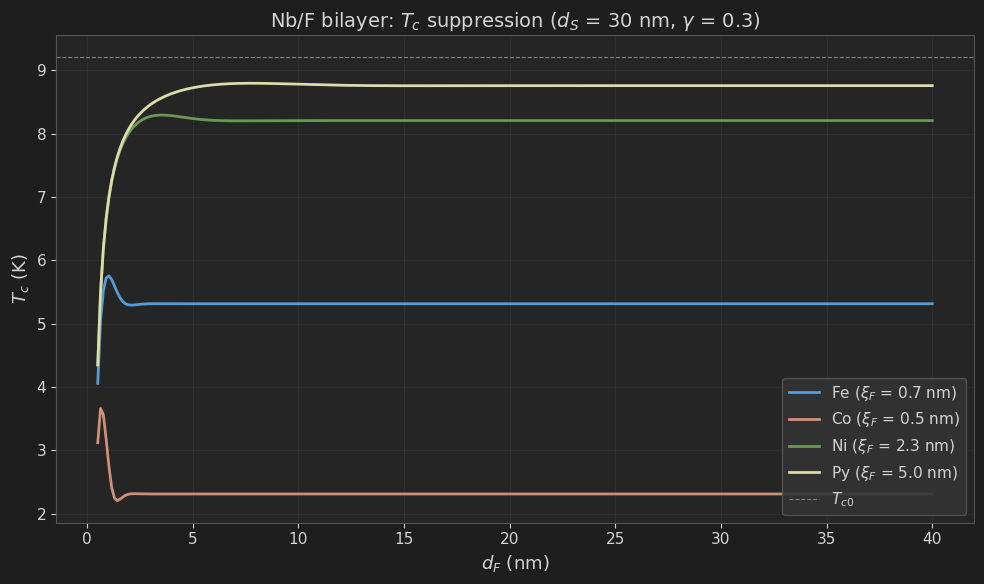

In [2]:
ferromagnets = ["Fe", "Co", "Ni", "Py"]

fig, ax = plt.subplots(figsize=(10, 6))

for fm_name in ferromagnets:
    fm = supermag.get_material(fm_name)
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=d_S_ref,
        d_F_array=d_F,
        E_ex=fm["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=fm["xi_F"],
        gamma=gamma_ref,
    )
    ax.plot(d_F, Tc, linewidth=2,
            label=f"{fm_name} ($\\xi_F$ = {fm['xi_F']} nm)")

ax.axhline(y=nb["Tc"], ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$T_c$ (K)")
ax.set_title(f"Nb/F bilayer: $T_c$ suppression ($d_S$ = {d_S_ref:.0f} nm, $\\gamma$ = {gamma_ref})")
ax.legend()
fig.tight_layout()
plt.show()

## Thickness Sweep of the S Layer

How does $T_c$ depend on the **superconductor** thickness $d_S$?

In the thin-S model, the coupling parameter encodes the geometry:
$\gamma \propto \xi_S / d_S$. So when we vary $d_S$, we must scale $\gamma$
accordingly: $\gamma(d_S) = \gamma_{\text{ref}} \times d_{S,\text{ref}} / d_S$.

Thinner S layers → larger effective $\gamma$ → stronger proximity effect
→ deeper $T_c$ suppression and more visible oscillatory structure.

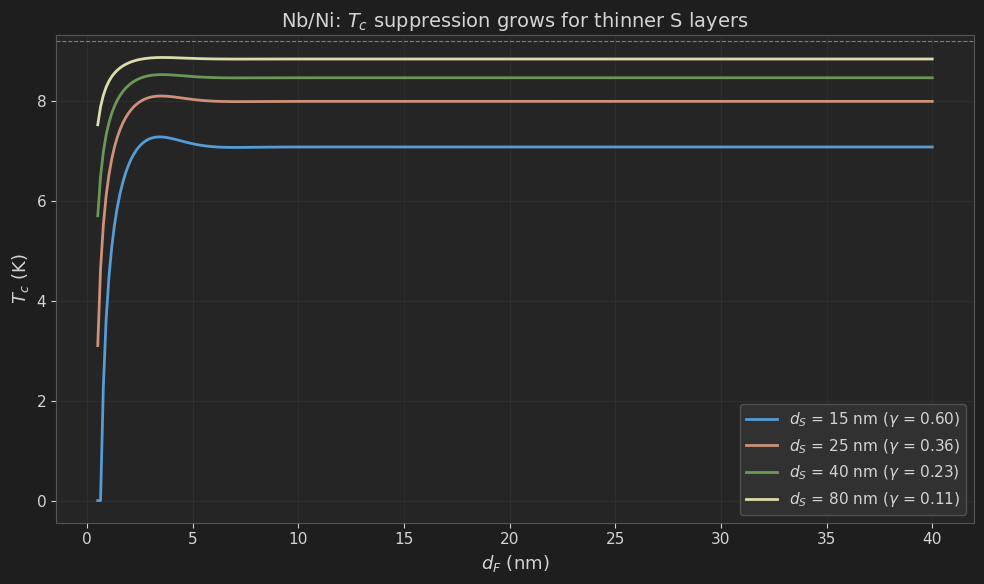

In [3]:
ni = supermag.get_material("Ni")
d_S_values = [15, 25, 40, 80]  # nm

fig, ax = plt.subplots(figsize=(10, 6))

for d_S in d_S_values:
    gamma_eff = gamma_ref * d_S_ref / d_S  # scale gamma with d_S
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=d_S,
        d_F_array=d_F,
        E_ex=ni["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=ni["xi_F"],
        gamma=gamma_eff,
    )
    ax.plot(d_F, Tc, linewidth=2,
            label=f"$d_S$ = {d_S} nm ($\\gamma$ = {gamma_eff:.2f})")

ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.8)
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$T_c$ (K)")
ax.set_title(r"Nb/Ni: $T_c$ suppression grows for thinner S layers")
ax.legend()
fig.tight_layout()
plt.show()

## Model Comparison: Thin-S vs. Fominov

SUPERMag implements two models for $T_c$ determination:

| Model | Applicable when | Key approximation |
|-------|----------------|-------------------|
| `thin_s` | $d_S \ll \xi_S$ | Order parameter uniform across S |
| `fominov` | Arbitrary $d_S$ | Includes boundary resistance $\gamma_B$ |

Let's compare them for a weak ferromagnet where the difference is visible.

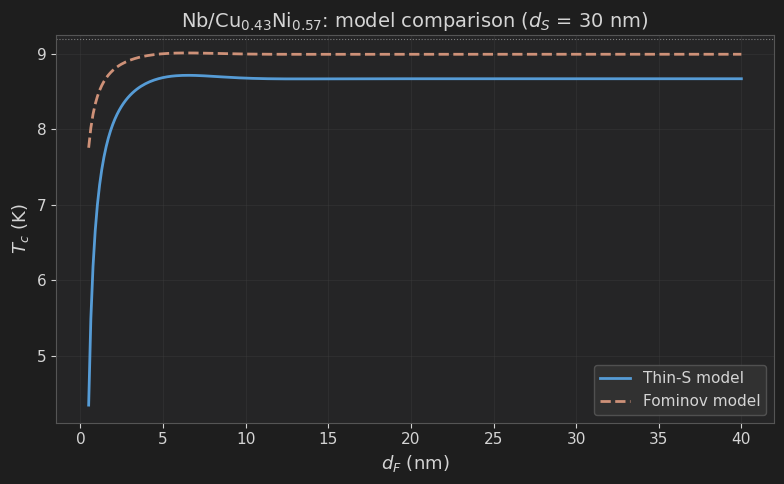

In [4]:
cuni = supermag.get_material("Cu0.43Ni0.57")

fig, ax = plt.subplots(figsize=(8, 5))

for model, ls, label in [("thin_s", "-", "Thin-S model"),
                          ("fominov", "--", "Fominov model")]:
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"],
        d_S=d_S_ref,
        d_F_array=d_F,
        E_ex=cuni["E_ex"],
        xi_S=nb["xi_S"],
        xi_F=cuni["xi_F"],
        gamma=gamma_ref,
        gamma_B=0.3,
        model=model,
    )
    ax.plot(d_F, Tc, ls=ls, linewidth=2, label=label)

ax.axhline(nb["Tc"], ls=":", color="gray", linewidth=0.8)
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$T_c$ (K)")
ax.set_title(r"Nb/Cu$_{0.43}$Ni$_{0.57}$: model comparison ($d_S$ = "
             f"{d_S_ref:.0f} nm)")
ax.legend()
fig.tight_layout()
plt.show()

## Saving Results

Export data as CSV for further analysis or publication-quality plotting.

In [5]:
# Example: save one curve
Tc_final = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=d_S_ref, d_F_array=d_F,
    E_ex=ni["E_ex"], xi_S=nb["xi_S"], xi_F=ni["xi_F"],
    gamma=gamma_ref,
)

data = np.column_stack([d_F, Tc_final])
# np.savetxt("nb_ni_tc_vs_df.csv", data, delimiter=",",
#            header="d_F_nm,Tc_K", comments="")
print(f"Data shape: {data.shape}")
print(f"First 5 rows:")
print(data[:5])

Data shape: (300, 2)
First 5 rows:
[[0.5        4.34747513]
 [0.63210702 5.48724881]
 [0.76421405 6.18043743]
 [0.89632107 6.65031817]
 [1.02842809 6.99013782]]
